# Part I - Exploration of Ford GoBike System Data (Feb 2019)
**Author:** Romaine Vassell  

## Dataset
This dataset contains individual ride records from the Ford GoBike system. Each row represents a single trip and includes trip duration, start/end times, station information, rider attributes, and membership type.

## Key Questions
This exploration focuses on:
- What is the distribution of trip duration?
- When do trips occur most frequently?
- How do trip patterns differ by user type (Subscriber vs Customer)?
- How do duration and distance relate, and does that relationship vary across user groups?

Throughout the notebook I use the **Question → Visualization → Observations** framework.


In [68]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")

# Load data
df = pd.read_csv("FordGoBikeSystemData.csv")
df.head()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,2019-02-28 17:32:10.1450,2019-03-01 08:01:55.9750,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,2019-02-28 18:53:21.7890,2019-03-01 06:42:03.0560,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,2019-02-28 12:13:13.2180,2019-03-01 05:24:08.1460,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,2019-02-28 17:54:26.0100,2019-03-01 04:02:36.8420,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,2019-02-28 23:54:18.5490,2019-03-01 00:20:44.0740,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


## Load Data

In [69]:
# Load the dataset
df = pd.read_csv("FordGoBikeSystemData.csv")
df.shape


(183412, 16)

In [70]:
df.head()


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,2019-02-28 17:32:10.1450,2019-03-01 08:01:55.9750,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,2019-02-28 18:53:21.7890,2019-03-01 06:42:03.0560,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,2019-02-28 12:13:13.2180,2019-03-01 05:24:08.1460,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,2019-02-28 17:54:26.0100,2019-03-01 04:02:36.8420,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,2019-02-28 23:54:18.5490,2019-03-01 00:20:44.0740,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


In [71]:
df.dtypes

duration_sec                 int64
start_time                  object
end_time                    object
start_station_id           float64
start_station_name          object
start_station_latitude     float64
start_station_longitude    float64
end_station_id             float64
end_station_name            object
end_station_latitude       float64
end_station_longitude      float64
bike_id                      int64
user_type                   object
member_birth_year          float64
member_gender               object
bike_share_for_all_trip     object
dtype: object

### What is the structure of your dataset?

> The dataset contains trip data from the Ford GoBike bike‑sharing system.  
Each row represents a single bike trip taken by a user.

The dataset contains **183,412 trips and 16 variables**. These variables include:
- Trip duration
- Start and end station information
- Geographic coordinates
- User type (Customer or Subscriber)
- Rider demographics such as gender and birth year

The dataset includes a mix of **numerical, categorical, and datetime variables** which allow exploration of riding behavior across time, distance, and user groups.


### What is/are the main feature(s) of interest in your dataset?

> 
The main features of interest in this dataset include trip duration, user type, and trip distance. These variables provide insight into how riders use the bike-sharing system and whether different types of riders exhibit different travel behaviors.

Trip duration helps us understand how long users typically ride bikes within the system. User type distinguishes between Subscribers, who are likely regular commuters, and Customers, who may use the system for occasional or recreational trips. Trip distance provides additional context for understanding how far riders typically travel during a trip.

By examining these features, we can investigate patterns in rider behavior and determine whether differences exist between user groups.

### What features in the dataset do you think will help support your investigation into your feature(s) of interest?

>
Several additional variables in the dataset help support the investigation. These include start time, start and end station coordinates, gender, and bike ID.

The start time variable allows us to extract additional time-based features such as hour of the day and day of the week. These features can help identify patterns in bike usage during different times of the day or different days of the week.

Station coordinates enable the calculation of approximate trip distance using geographic formulas. Demographic variables such as gender can also help explore differences in usage patterns among riders.

Together, these supporting variables provide useful context for analyzing the primary variables of interest.


## Preliminary Wrangling

### Data Types, Missing Values, and Basic Checks

**Question:** What columns exist, what are their data types, and where are the missing values?

**Visualization:** Tables (info + missingness summary)

**Observations:** We'll use this to decide what cleaning and feature engineering is needed before plotting.


In [72]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183412 entries, 0 to 183411
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183412 non-null  int64  
 1   start_time               183412 non-null  object 
 2   end_time                 183412 non-null  object 
 3   start_station_id         183215 non-null  float64
 4   start_station_name       183215 non-null  object 
 5   start_station_latitude   183412 non-null  float64
 6   start_station_longitude  183412 non-null  float64
 7   end_station_id           183215 non-null  float64
 8   end_station_name         183215 non-null  object 
 9   end_station_latitude     183412 non-null  float64
 10  end_station_longitude    183412 non-null  float64
 11  bike_id                  183412 non-null  int64  
 12  user_type                183412 non-null  object 
 13  member_birth_year        175147 non-null  float64
 14  memb

In [73]:
# Missingness summary
df.isna().mean().sort_values(ascending=False)


member_birth_year          0.045062
member_gender              0.045062
start_station_id           0.001074
start_station_name         0.001074
end_station_id             0.001074
end_station_name           0.001074
duration_sec               0.000000
start_time                 0.000000
end_time                   0.000000
start_station_latitude     0.000000
start_station_longitude    0.000000
end_station_latitude       0.000000
end_station_longitude      0.000000
bike_id                    0.000000
user_type                  0.000000
bike_share_for_all_trip    0.000000
dtype: float64

### Feature Engineering Plan

From the raw columns, the analysis will benefit from:
- Converting `start_time` and `end_time` to datetime.
- Creating `duration_min` for interpretability.
- Creating `member_age` from birth year (with outlier handling).
- Creating trip `distance_km` from start/end coordinates (haversine).
- Creating time features: `start_hour`, `start_dayofweek`, `is_weekend`.


In [74]:
# Convert datetime columns
df["start_time"] = pd.to_datetime(df["start_time"])
df["end_time"] = pd.to_datetime(df["end_time"])

# Duration in minutes
df["duration_min"] = df["duration_sec"] / 60

# Time features
df["start_hour"] = df["start_time"].dt.hour
df["start_dayofweek"] = df["start_time"].dt.day_name()
df["is_weekend"] = df["start_time"].dt.dayofweek >= 5

# Age (approx) based on 2019 since data is Feb 2019
df["member_age"] = 2019 - df["member_birth_year"]

df[["duration_sec", "duration_min", "start_time", "start_hour", "start_dayofweek", "member_birth_year", "member_age"]].head()


,duration_sec,duration_min,start_time,start_hour,start_dayofweek,member_birth_year,member_age
0,52185,869.750000,2019-02-28 17:32:10.145,17,Thursday,1984.0,35.0
1,42521,708.683333,2019-02-28 18:53:21.789,18,Thursday,NaN,NaN
2,61854,1030.900000,2019-02-28 12:13:13.218,12,Thursday,1972.0,47.0
3,36490,608.166667,2019-02-28 17:54:26.010,17,Thursday,1989.0,30.0
4,1585,26.416667,2019-02-28 23:54:18.549,23,Thursday,1974.0,45.0


In [75]:
# Haversine distance in km between start and end coordinates
def haversine_km(lat1, lon1, lat2, lon2):
    """Compute great-circle distance between two points (in decimal degrees)."""
    # convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371  # Earth radius (km)
    return c * r

df["distance_km"] = haversine_km(
    df["start_station_latitude"],
    df["start_station_longitude"],
    df["end_station_latitude"],
    df["end_station_longitude"],
)

df["distance_km"].describe()


count    183412.000000
mean          1.690659
std           1.097589
min           0.000000
25%           0.910955
50%           1.430738
75%           2.225687
max          69.469241
Name: distance_km, dtype: float64

### Cleaning Decisions

We will:
- Remove trips with missing coordinates (distance cannot be computed).
- Handle extreme values:
  - Very long durations are uncommon and can dominate plots (use filtering for some charts).
  - Ages outside a reasonable range (e.g., < 16 or > 90) are treated as outliers and set to NaN for age analyses.


In [76]:
# Drop rows missing coordinates needed for distance
coord_cols = [
    "start_station_latitude", "start_station_longitude",
    "end_station_latitude", "end_station_longitude"
]
df_clean = df.dropna(subset=coord_cols).copy()

# Age outliers
df_clean.loc[(df_clean["member_age"] < 16) | (df_clean["member_age"] > 90), "member_age"] = np.nan

df_clean.shape


(183412, 22)

In [77]:
df_clean[["duration_min", "distance_km", "member_age"]].describe()


,duration_min,distance_km,member_age
count,183412.000000,183412.000000,175070.000000
mean,12.101307,1.690659,34.157011
std,29.906496,1.097589,9.966723
min,1.016667,0.000000,18.000000
25%,5.416667,0.910955,27.000000
50%,8.566667,1.430738,32.000000
75%,13.266667,2.225687,39.000000
max,1424.066667,69.469241,89.000000


# Univariate Exploration

## 1) Trip Duration Distribution (Histogram) — **Required**

**Question:** How long are typical trips?

**Visualization:** Histogram of `duration_min` with a vertical line showing the mean.

**Observations:** Expect a right-skewed distribution (many short trips, few very long trips). We'll use a reasonable x-limit to avoid extreme outliers dominating the view.


In [78]:
# Optional: remove impossible/rare values to avoid extreme axis scaling in plots
# (keeps the main data intact while improving readability)
df_plot = df.copy()
df_plot = df_plot[df_plot['duration_sec'].between(1, df_plot['duration_sec'].quantile(0.99))]
df_plot = df_plot[df_plot['distance_km'].between(0, df_plot['distance_km'].quantile(0.99))]
df_plot.shape


(179768, 22)

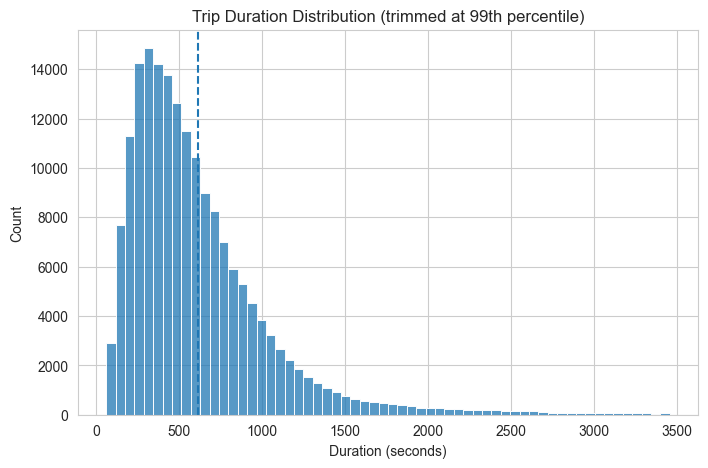

In [79]:
plt.figure(figsize=(8,5))
sns.histplot(df_plot['duration_sec'], bins=60)
plt.axvline(df_plot['duration_sec'].mean(), linestyle='--')
plt.title("Trip Duration Distribution (trimmed at 99th percentile)")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.show()

### 2) Histogram — Trip Distance (km)

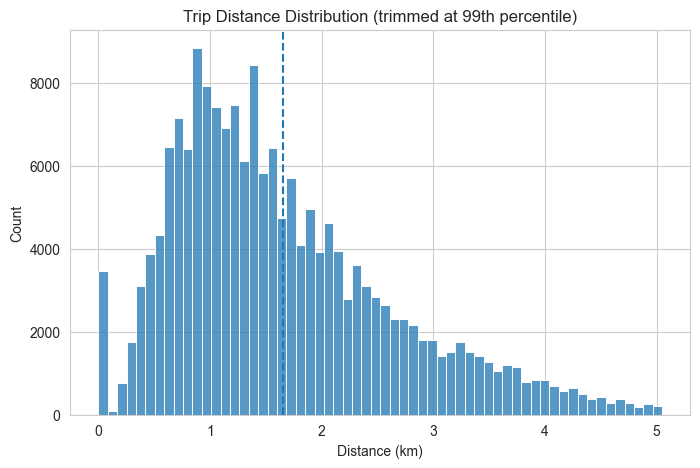

In [80]:
plt.figure(figsize=(8,5))
sns.histplot(df_plot['distance_km'], bins=60)
plt.axvline(df_plot['distance_km'].mean(), linestyle='--')
plt.title("Trip Distance Distribution (trimmed at 99th percentile)")
plt.xlabel("Distance (km)")
plt.ylabel("Count")
plt.show()


### 3) Count Plot — User Type

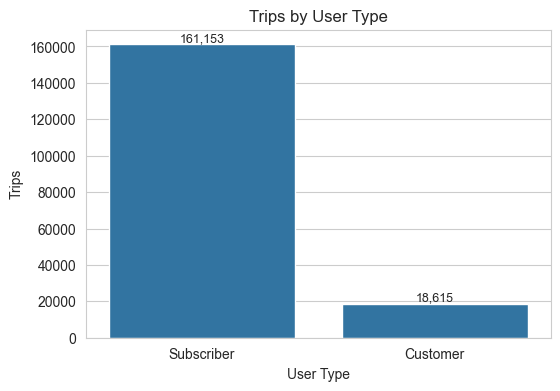

In [81]:
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df_plot, x='user_type')
plt.title("Trips by User Type")
plt.xlabel("User Type")
plt.ylabel("Trips")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.show()

### 4) Count Plot — Gender

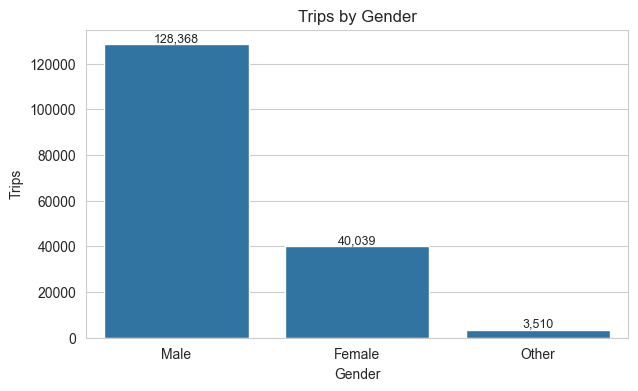

In [82]:
plt.figure(figsize=(7,4))
ax = sns.countplot(data=df_plot, x='member_gender', order=df_plot['member_gender'].value_counts().index)
plt.title("Trips by Gender")
plt.xlabel("Gender")
plt.ylabel("Trips")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.show()


### 5) Count Plot — Day of Week

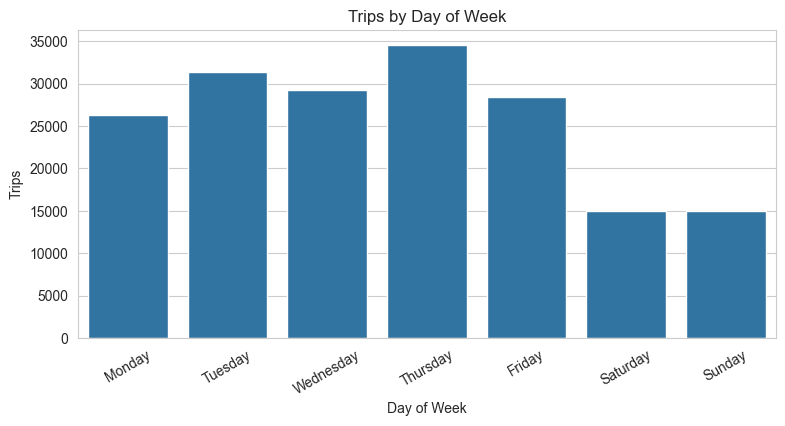

In [83]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
plt.figure(figsize=(9,4))
ax = sns.countplot(data=df_plot, x='start_dayofweek', order=order)
plt.title("Trips by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Trips")
plt.xticks(rotation=30)
plt.show()


### 6) Histogram — Hour of Day

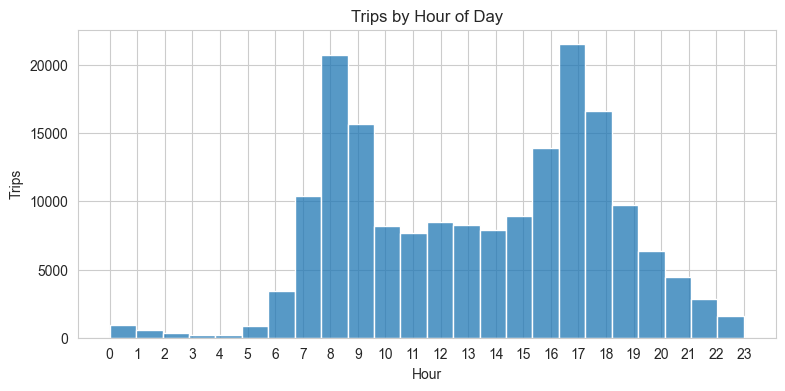

In [84]:
plt.figure(figsize=(9,4))
sns.histplot(df_plot['start_hour'].dropna(), bins=24)
plt.title("Trips by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Trips")
plt.xticks(range(0,24))
plt.show()


# Bivariate Exploration

Before plotting, I expect:
- Longer distances to generally imply longer durations.
- Customers (casual riders) to potentially have longer durations than Subscribers.

I'll test these ideas with a scatterplot and a boxplot, plus a correlation heatmap.


## 7) Duration vs Distance (Scatterplot) — **Required**

**Question:** Do longer trips (distance) generally take longer (duration)?

**Visualization:** Scatterplot of `distance_km` vs `duration_min` (with transparency to reduce overplotting).

**Observations:** Look for an upward trend and any clusters near short-distance/short-duration trips.


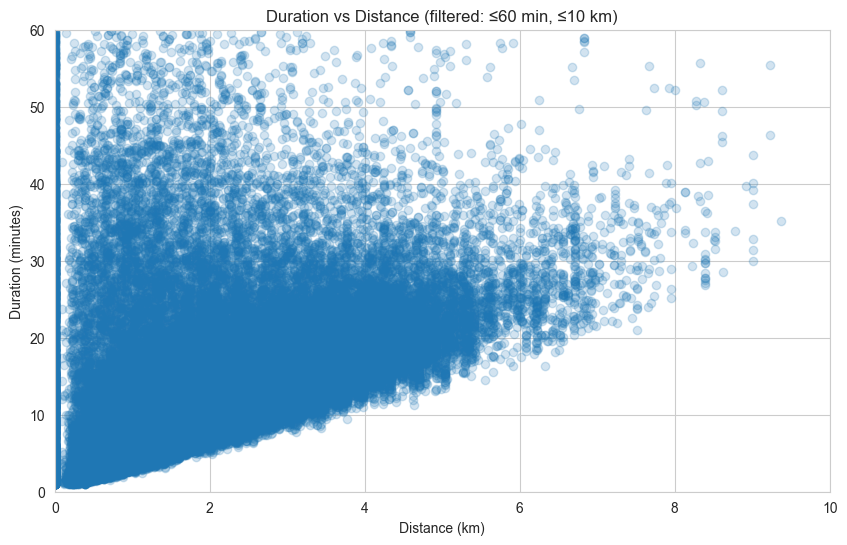

In [85]:
plt.figure(figsize=(10, 6))
plot_df = df_clean[(df_clean["duration_min"] <= 60) & (df_clean["distance_km"] <= 10)]
plt.scatter(plot_df["distance_km"], plot_df["duration_min"], alpha=0.2)
plt.title("Duration vs Distance (filtered: ≤60 min, ≤10 km)")
plt.xlabel("Distance (km)")
plt.ylabel("Duration (minutes)")
plt.xlim(0, 10)
plt.ylim(0, 60)
plt.show()


## 8) Duration by User Type (Box Plot) — **Required**

**Question:** Do Subscribers and Customers differ in typical trip duration?

**Visualization:** Box plot of `duration_min` by `user_type` (filtered to ≤60 minutes).

**Observations:** Compare medians and spread; boxplots are robust to skew and outliers (but we still filter for readability).



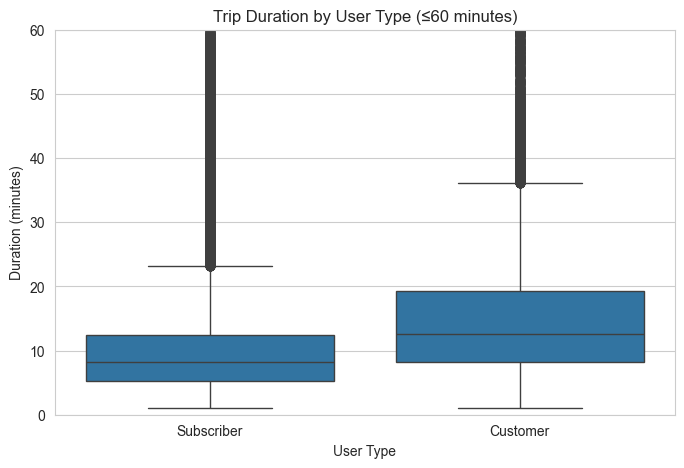

,count,mean,50%
user_type,,,
Customer,18861.0,15.224379,12.65
Subscriber,162841.0,9.835612,8.15


In [86]:
plt.figure(figsize=(8, 5))
plot_df = df_clean[df_clean["duration_min"] <= 60]
sns.boxplot(data=plot_df, x="user_type", y="duration_min")
plt.title("Trip Duration by User Type (≤60 minutes)")
plt.xlabel("User Type")
plt.ylabel("Duration (minutes)")
plt.ylim(0, 60)
plt.show()

plot_df.groupby("user_type")["duration_min"].describe()[["count","mean","50%"]]


### 9) Box Plot — Duration vs Gender

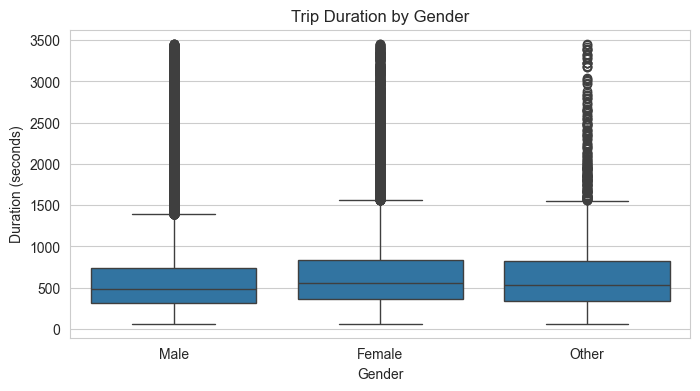

In [87]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df_plot, x='member_gender', y='duration_sec')
plt.title("Trip Duration by Gender")
plt.xlabel("Gender")
plt.ylabel("Duration (seconds)")
plt.show()


### 10) Scatterplot — Duration vs Distance
The scatterplot shows a positive relationship between trip distance and trip duration. As expected, longer distances generally require longer travel times. However, the relationship is not perfectly linear, suggesting that other factors such as route choice or traffic conditions may also influence trip duration.

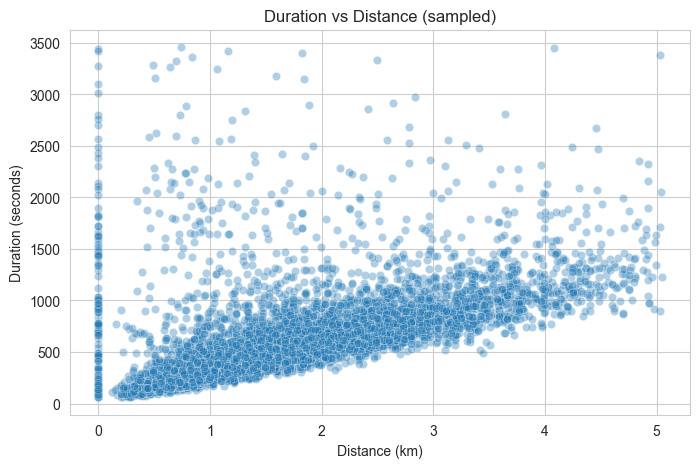

In [88]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_plot.sample(7000, random_state=42), x='distance_km', y='duration_sec', alpha=0.35)
plt.title("Duration vs Distance (sampled)")
plt.xlabel("Distance (km)")
plt.ylabel("Duration (seconds)")
plt.show()


### 11) Bar Chart — Average Duration by Day of Week
The average trip duration varies slightly across days of the week. Some days show slightly longer average trip durations, which may indicate differences in travel behavior between weekdays and weekends.


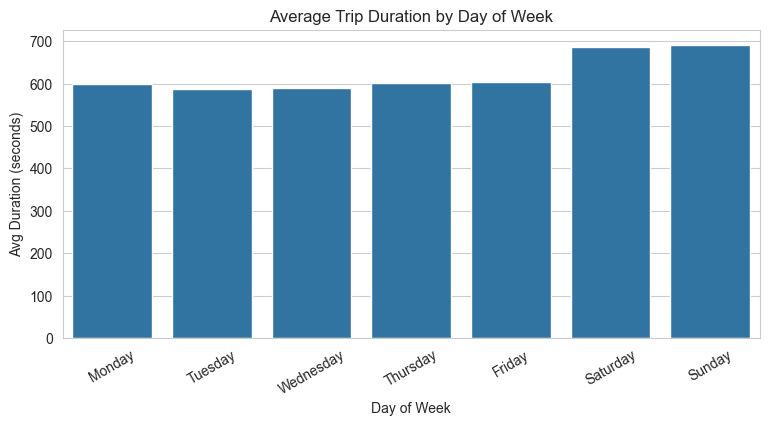

In [89]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
avg_day = df_plot.groupby('start_dayofweek', as_index=False)['duration_sec'].mean()
plt.figure(figsize=(9,4))
sns.barplot(data=avg_day, x='start_dayofweek', y='duration_sec', order=order)
plt.title("Average Trip Duration by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Avg Duration (seconds)")
plt.xticks(rotation=30)
plt.show()

### 12) Clustered Count Plot — Day of Week by User Type

Subscribers consistently make up the majority of trips across all days of the week. However, Customer usage appears slightly more prominent on weekends, suggesting that occasional users may be more active during leisure periods.

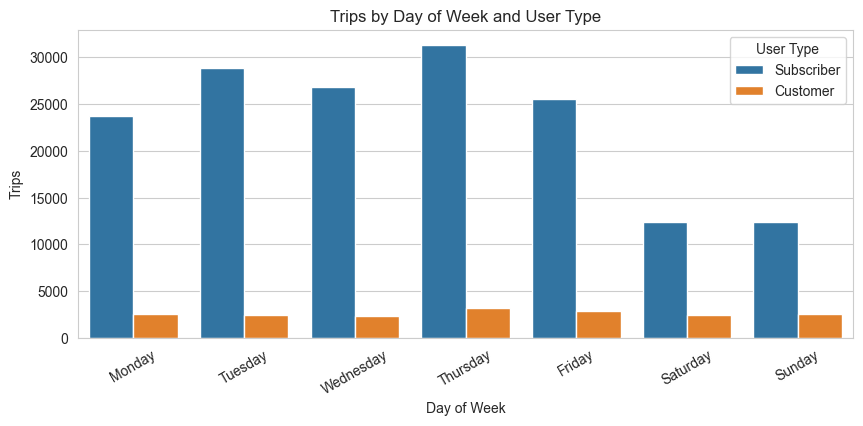

In [90]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
plt.figure(figsize=(10,4))
sns.countplot(data=df_plot, x='start_dayofweek', hue='user_type', order=order)
plt.title("Trips by Day of Week and User Type")
plt.xlabel("Day of Week")
plt.ylabel("Trips")
plt.xticks(rotation=30)
plt.legend(title="User Type")
plt.show()

## 13) Numeric Correlation Heatmap — **Additional Bivariate Visualization**

**Question:** Which numeric variables are most strongly correlated?

**Visualization:** Correlation heatmap (annotated).

**Observations:** Helps confirm whether distance is a strong driver of duration and whether age has much relationship to trip metrics.


The correlation heatmap shows a moderate relationship between trip duration and distance, which is expected since longer trips typically take more time. Other variables such as hour show weaker correlations with trip duration.


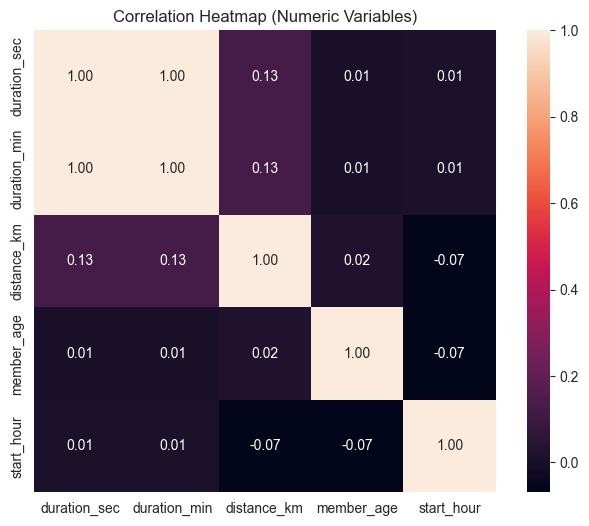

In [91]:
numeric_cols = ["duration_sec", "duration_min", "distance_km", "member_age", "start_hour"]
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", square=True)
plt.title("Correlation Heatmap (Numeric Variables)")
plt.show()


# Multivariate Exploration

In multivariate exploration, I will add a third variable (user type, weekday/weekend) to understand whether patterns hold across groups.

Required: <br>**Facet plot**  <br>
**Scatterplot with multiple encodings**<br>
**Clustered Bar Chart**<br>
 **Plot Matrix (Pairplot)**<br>

### 14 Facet Plot — Hour Distribution by User Type

When separating trips by user type, Subscribers show clear peaks during morning and evening commuting hours. Customers show a more evenly distributed pattern throughout the day, which may indicate recreational or flexible travel behavior.


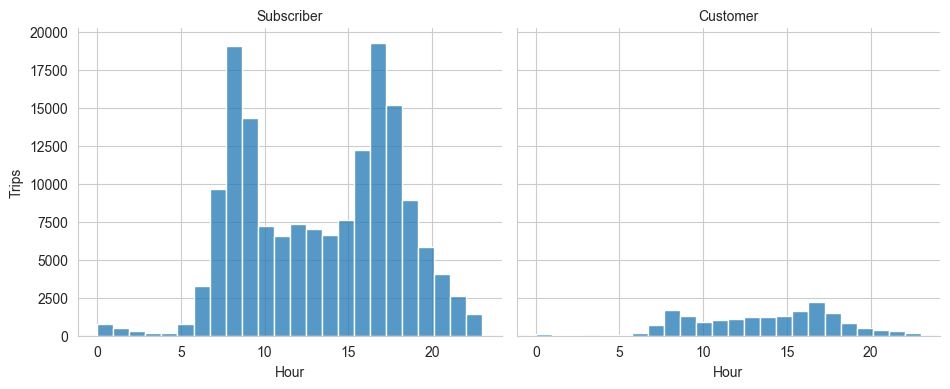

In [92]:
g = sns.FacetGrid(df_plot, col='user_type', height=4, aspect=1.2)
g.map_dataframe(sns.histplot, x='start_hour', bins=24)
g.set_axis_labels("Hour", "Trips")
g.set_titles(col_template="{col_name}")
plt.show()


## 15) Duration by Day of Week, Faceted by User Type — **Required Facet Plot**

**Question:** Do trip durations vary across the week, and does that pattern differ between Subscribers and Customers?

**Visualization:** Faceted boxplots of `duration_min` by day-of-week, split by `user_type`.

**Observations:** Subscribers often show commute-like patterns (weekday consistency), while Customers may show different weekend behavior.


When separating trips by user type, Subscribers show clear peaks during morning and evening commuting hours. Customers show a more evenly distributed pattern throughout the day, which may indicate recreational or flexible travel behavior.


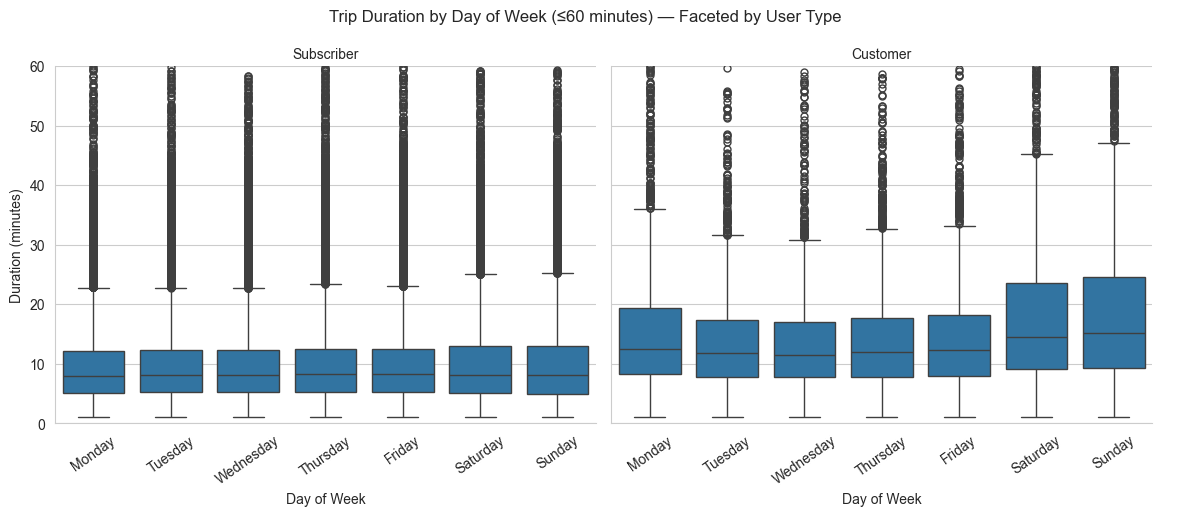

In [93]:
# Order days for readability
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
plot_df = df_clean[df_clean["duration_min"] <= 60].copy()
plot_df["start_dayofweek"] = pd.Categorical(plot_df["start_dayofweek"], categories=day_order, ordered=True)

g = sns.catplot(
    data=plot_df,
    x="start_dayofweek",
    y="duration_min",
    col="user_type",
    kind="box",
    height=4.5,
    aspect=1.3
)
g.set_titles("{col_name}")
g.set_axis_labels("Day of Week", "Duration (minutes)")
for ax in g.axes.flatten():
    ax.set_ylim(0, 60)
    ax.tick_params(axis='x', rotation=35)
plt.suptitle("Trip Duration by Day of Week (≤60 minutes) — Faceted by User Type", y=1.05)
plt.show()


## 16) Duration vs Distance with Multiple Encodings 

**Question:** Does the distance–duration relationship differ by user type and gender?

**Visualization:** Scatterplot with:
- x = distance
- y = duration
- color = user_type
- style = member_gender

**Observations:** This can reveal whether one group tends to take longer trips for the same distance (possible slower pace, more stops, leisure riding).


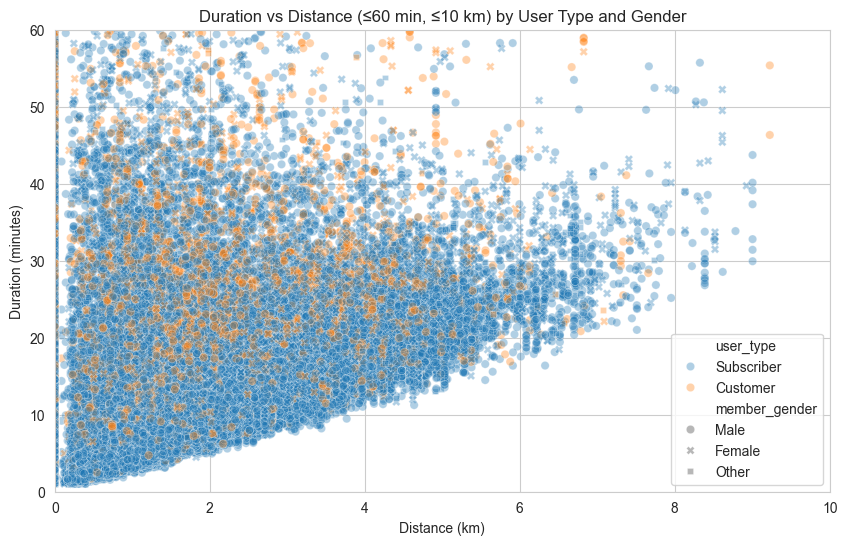

In [94]:
plot_df = df_clean[
    (df_clean["duration_min"] <= 60) &
    (df_clean["distance_km"] <= 10) &
    (df_clean["member_gender"].notna())
].copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df,
    x="distance_km",
    y="duration_min",
    hue="user_type",
    style="member_gender",
    alpha=0.35
)
plt.title("Duration vs Distance (≤60 min, ≤10 km) by User Type and Gender")
plt.xlabel("Distance (km)")
plt.ylabel("Duration (minutes)")
plt.xlim(0, 10)
plt.ylim(0, 60)
plt.show()


### 17) Clustered Bar Chart — Avg Duration by Day and User Type

This visualization shows that Customers tend to have slightly longer average trip durations compared to Subscribers across most days of the week. This supports the idea that Customers may use the service more for leisure activities.


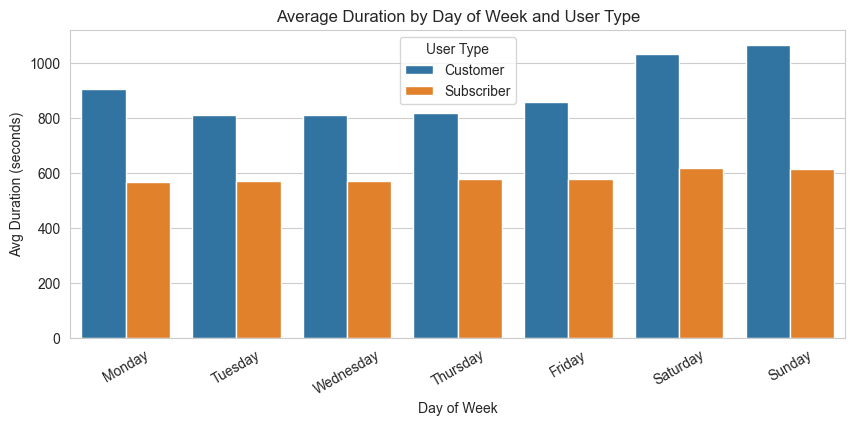

In [95]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = df_plot.groupby(['start_dayofweek','user_type'], as_index=False)['duration_sec'].mean()
plt.figure(figsize=(10,4))
sns.barplot(data=pivot, x='start_dayofweek', y='duration_sec', hue='user_type', order=order)
plt.title("Average Duration by Day of Week and User Type")
plt.xlabel("Day of Week")
plt.ylabel("Avg Duration (seconds)")
plt.xticks(rotation=30)
plt.legend(title="User Type")
plt.show()


### 18) Plot Matrix — Numeric Features

The pairplot highlights the relationships between key numeric variables. The strongest relationship appears between trip duration and trip distance, confirming earlier observations that longer distances generally result in longer trip times.


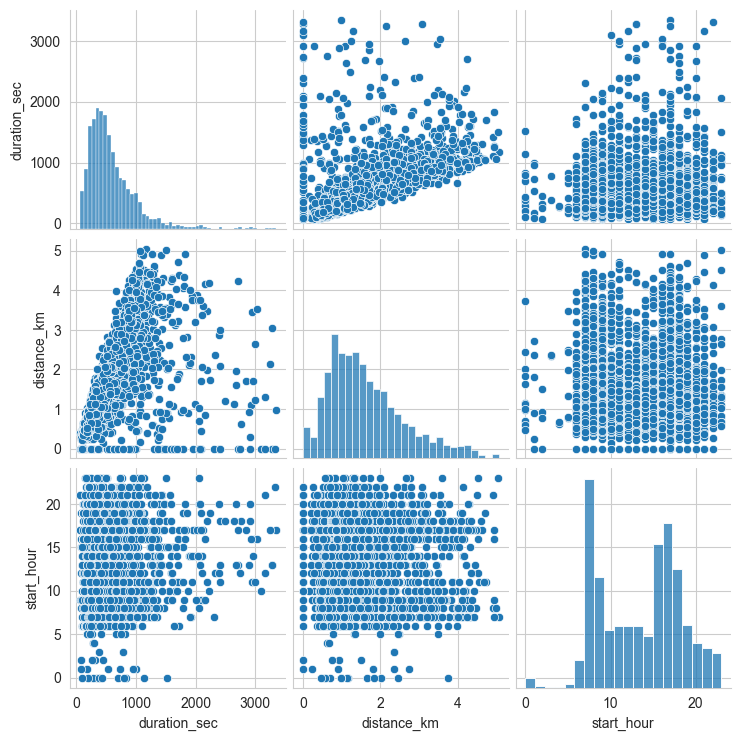

In [96]:
# Pairplot can be slow; sample for speed.
sample_df = df_plot[['duration_sec','distance_km','start_hour']].dropna().sample(2500, random_state=123)
sns.pairplot(sample_df)
plt.show()

### Talk about some of the relationships you observed in this part of the investigation. Were there features that strengthened each other in terms of looking at your feature(s) of interest?

> Several relationships between variables became evident during the exploration. One of the clearest relationships was between trip distance and trip duration, where longer distances generally corresponded with longer travel times. This positive relationship was visible in the scatterplots and confirms expected travel behavior.

Another important relationship involved user type and trip duration. Subscribers tended to have shorter and more consistent trip durations, suggesting routine commuting patterns. In contrast, Customers showed greater variability and often slightly longer trip durations, which may indicate recreational or occasional usage.

Time-related features such as hour of the day and day of the week also strengthened the analysis. Subscriber activity showed noticeable peaks during typical commuting hours on weekdays, while Customer usage appeared more evenly distributed and slightly more prominent on weekends. These relationships helped provide deeper insight into how different types of riders use the bike-sharing system.


### Were there any interesting or surprising interactions between features?

> One interesting interaction observed in the analysis was the difference in behavior between Subscribers and Customers across different times of the week. Subscribers displayed a more predictable usage pattern, with activity concentrated during weekday commuting hours. Customers, however, showed more flexibility in their riding patterns and appeared to ride more frequently during weekends and non-commuting hours.

Another notable observation was that Customers often had longer median trip durations compared to Subscribers, despite making fewer total trips. This suggests that Customers may use the bike-sharing system more for leisure activities rather than regular commuting.

Overall, these interactions highlight how rider type plays a significant role in shaping usage patterns within the bike-sharing system.


# Conclusions

Key takeaways from this exploration (based on the visuals above):

- Trip durations are **strongly right-skewed**: most rides are short, with a long tail of longer trips.
- **Subscribers dominate trip volume**, suggesting many rides are routine/commute oriented.
- Distance and duration show a **positive relationship**, especially within common trip ranges.
- Customers tend to have **longer median trip durations** than Subscribers (within the same duration window), consistent with more leisure-oriented usage.
- Day-of-week patterns differ between user types: Subscribers are more consistent across weekdays; Customers show relatively stronger weekend patterns.

These insights will be refined into a short explanatory story in Part II.
